<a href="https://colab.research.google.com/github/Aaguilar123/Macro-Liquidity-Asset-Leaderboard-Forecast/blob/main/shared_eda/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

COMPREHENSIVE EDA & FEATURE ENGINEERING 
Total Trading Days: 4083
Daily Returns


/tmp/ipykernel_4114/1124875588.py:19: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_macro['CPI_Inflation'] = df_macro['CPI_Inflation'].pct_change(1) * 100


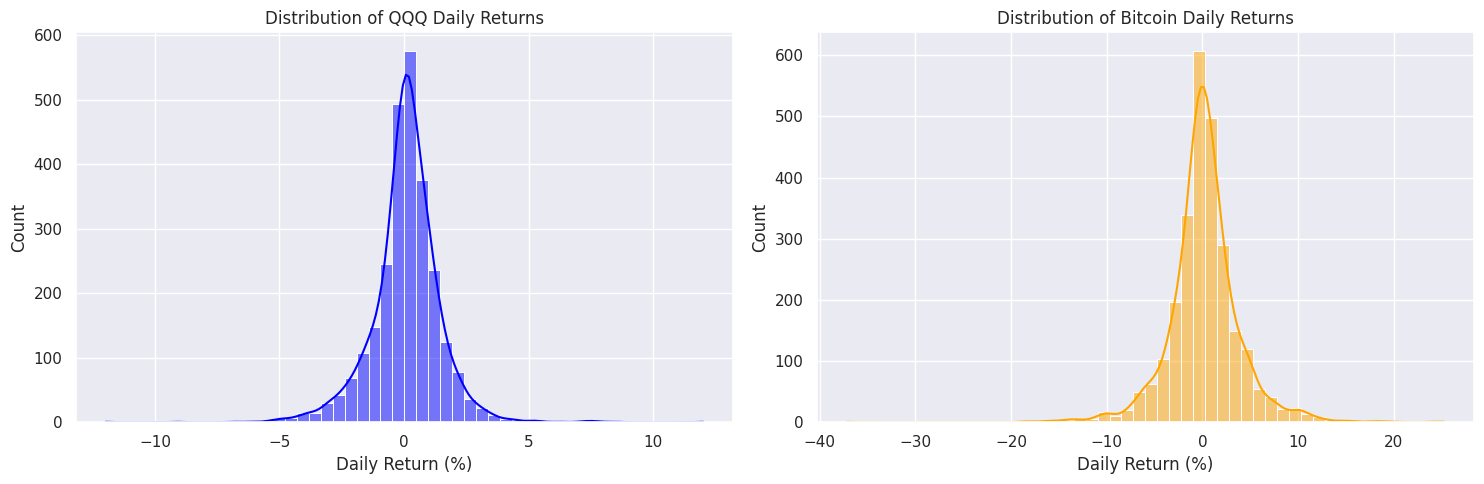


>>> Generating Correlation Heatmap...


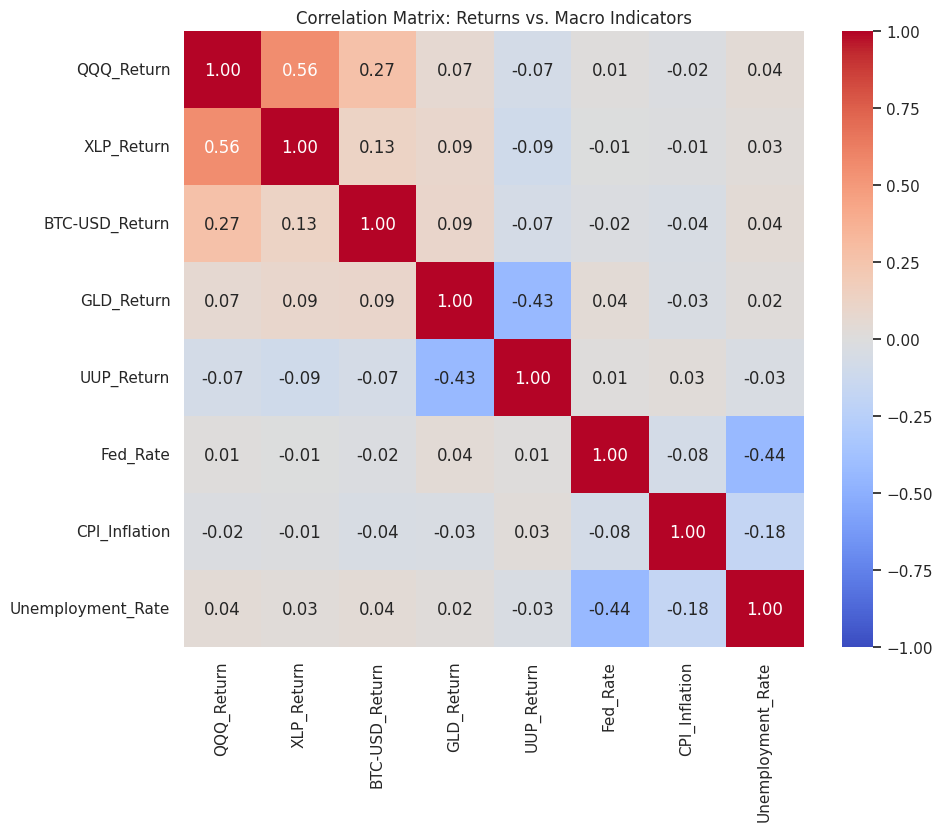


✅ EDA Complete! 'final_engineered_data.csv' is ready for modeling.

>>> Calculating Monthly Leaderboard Ranks...
            QQQ_Rank  XLP_Rank  GLD_Rank  BTC-USD_Rank  UUP_Rank  \
Date                                                               
2015-02-28       2.0       3.0       5.0           1.0       4.0   
2015-03-31       4.0       3.0       2.0           5.0       1.0   
2015-04-30       1.0       4.0       2.0           3.0       5.0   
2015-05-31       2.0       3.0       4.0           5.0       1.0   
2015-06-30       5.0       3.0       2.0           1.0       4.0   

           Monthly_Winner  
Date                       
2015-02-28        BTC-USD  
2015-03-31            UUP  
2015-04-30            QQQ  
2015-05-31            UUP  
2015-06-30        BTC-USD  


/tmp/ipykernel_4114/1124875588.py:87: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df_master[return_columns].resample('M').sum()


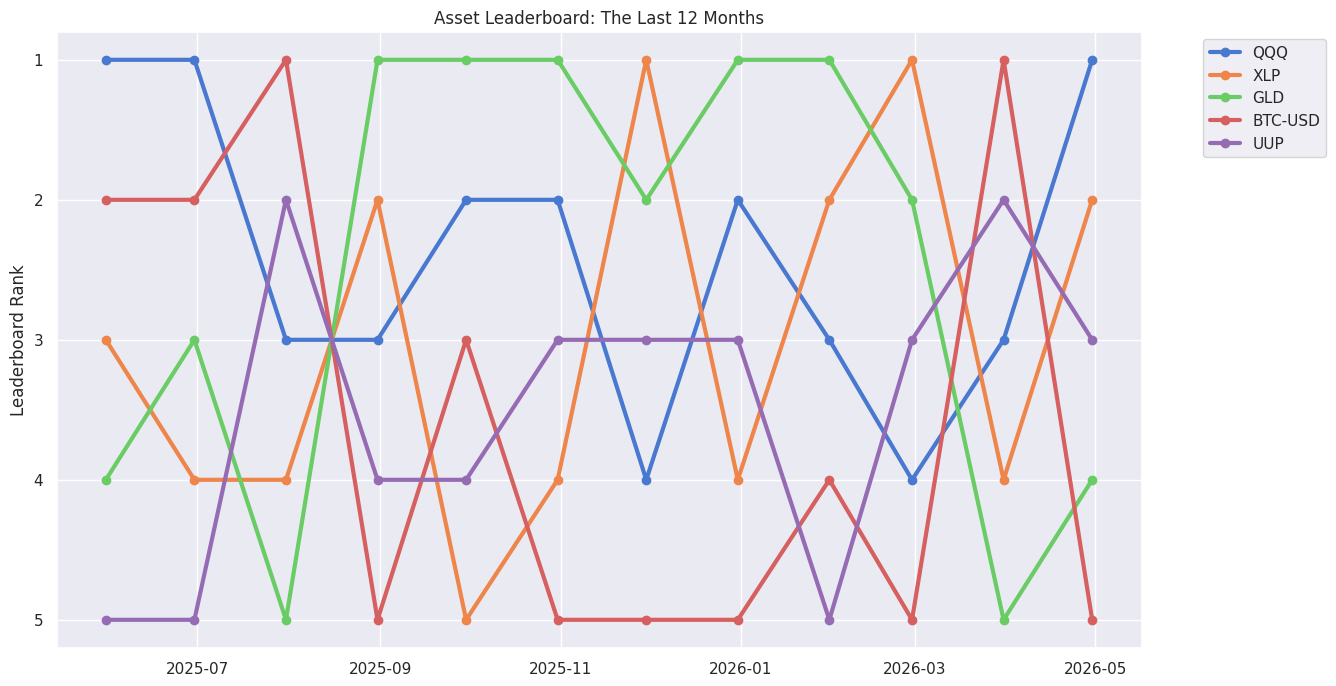

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for the team
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)

print("COMPREHENSIVE EDA & FEATURE ENGINEERING ")

# 1. LOAD & MERGE
df_prices = pd.read_csv('market_prices.csv', index_col='Date', parse_dates=True)
df_volume = pd.read_csv('market_volume.csv', index_col='Date', parse_dates=True)
df_macro = pd.read_csv('macro_indicators.csv', index_col='Date', parse_dates=True)

# ---> NEW FIX: Calculate Inflation Rate BEFORE forward-filling! <---
# Because df_macro is monthly here, pct_change(1) perfectly calculates Month-over-Month inflation
df_macro['CPI_Inflation'] = df_macro['CPI_Inflation'].pct_change(1) * 100

# Standardize index names
df_prices.index.name = 'Date'
df_volume.index.name = 'Date'
df_macro.index.name = 'Date'

# Left join to align everything to trading days, then forward-fill macro data
df_master = df_prices.join(df_volume, rsuffix='_Volume', how='left')
df_master = df_master.join(df_macro, how='left').ffill().dropna()

print(f"Total Trading Days: {len(df_master)}")

# 2. FEATURE ENGINEERING (Change to %)
# Machine learning models struggle with raw prices (like $400).
# They learn much better from "Returns" (like +1.5%).
print("Daily Returns")

# Calculate Daily Percentage Returns for all assets
for col in ['QQQ', 'XLP', 'GLD', 'BTC-USD', 'UUP']:
    df_master[f'{col}_Return'] = df_master[col].pct_change() * 100

df_master.dropna(inplace=True)

# ---> THE MASTER FILTER: Delete any row with a 0% change <---
# This checks all 5 return columns. If ANY of them are exactly 0.0, the entire row is deleted.
return_columns = ['QQQ_Return', 'XLP_Return', 'GLD_Return', 'BTC-USD_Return', 'UUP_Return']
df_master = df_master[(df_master[return_columns] != 0.0).all(axis=1)]

# 3. VISUALIZING DISTRIBUTIONS (Risk & Volatility QQQ vs BTC)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_master['QQQ_Return'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of QQQ Daily Returns')
axes[0].set_xlabel('Daily Return (%)')

sns.histplot(df_master['BTC-USD_Return'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Bitcoin Daily Returns')
axes[1].set_xlabel('Daily Return (%)')

plt.tight_layout()
plt.show()

# 4. CORRELATION ANALYSIS
print("\n>>> Generating Correlation Heatmap...")

# Select the features we actually care about comparing
features_to_correlate = ['QQQ_Return','XLP_Return', 'BTC-USD_Return', 'GLD_Return', 'UUP_Return','Fed_Rate', 'CPI_Inflation', 'Unemployment_Rate']

corr_matrix = df_master[features_to_correlate].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix: Returns vs. Macro Indicators')
plt.show()

# 5. SAVE THE FINAL "CLEAN" DATASET
# Now that we've engineered returns and MAs, we save this master file.
# THIS is the file your team will load into their XGBoost models!
df_master.to_csv('final_engineered_data.csv')
print("\n✅ EDA Complete! 'final_engineered_data.csv' is ready for modeling.")

# ==========================================
# 6. MONTHLY LEADERBOARD (The Horse Race)
# ==========================================
print("\n>>> Calculating Monthly Leaderboard Ranks...")

# 1. Resample to Monthly frequency
monthly_data = df_master[return_columns].resample('M').sum()

# 2. Create the Ranks (1 = Best Performer, 5 = Worst)
# We use .rank(ascending=False) so the highest return gets Rank 1
monthly_ranks = monthly_data.rank(axis=1, ascending=False)

# Rename columns to show they are Ranks
monthly_ranks.columns = [c.replace('_Return', '_Rank') for c in monthly_ranks.columns]

# 3. Find the Winner (#1) for each month
monthly_ranks['Monthly_Winner'] = monthly_data.idxmax(axis=1).str.replace('_Return', '')

print(monthly_ranks.head())

# 7. BUMP CHART: Asset Ranking Over Time
plt.figure(figsize=(14, 8))

# We only plot the last 12 months so the chart isn't too crowded
recent_ranks = monthly_ranks.iloc[-12:].copy()

for col in [c for c in recent_ranks.columns if '_Rank' in c]:
    plt.plot(recent_ranks.index, recent_ranks[col], marker='o', linewidth=3, label=col.replace('_Rank',''))

plt.gca().invert_yaxis() # Rank 1 should be at the top
plt.yticks([1, 2, 3, 4, 5])
plt.title('Asset Leaderboard: The Last 12 Months')
plt.ylabel('Leaderboard Rank')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()